# Differential expression + enrichment, no velocity layers

Kang IFN-β PBMC, 8 donors (GSE96583). Counts only. Wilcoxon, PyDESeq2
pseudobulk, and Memento on the same contrast, then ORA / GSEA / plots.

```bash
pip install "scatrans[pseudobulk,memento,gsea]"
```

**Data.** `kang_ifnb_tutorial_subset.h5ad` at the repo root. Citation:
{doc}`../references`. Mechanism path (needs nascent layers):
{doc}`t_gse226488_partition_mechanism`.


In [1]:
%matplotlib inline

In [2]:
import numpy as np
import scanpy as sc

import scatrans as scat

print("scatrans", scat.__version__)

scatrans 0.10.16


## Load


In [3]:
adata_full = sc.read_h5ad("../../kang_ifnb_tutorial_subset.h5ad")
adata_full

AnnData object with n_obs × n_vars = 3840 × 8680
    obs: 'condition', 'sample', 'celltype'
    var: 'n_cells'

In [4]:
adata_full.obs.groupby(["celltype", "condition"], observed=True).size().unstack()

condition,IFNb,control
celltype,,
CD14+ Monocytes,960,960
CD4 T cells,960,960


## CD14+ Monocytes


In [5]:
adata = adata_full[adata_full.obs["celltype"] == "CD14+ Monocytes"].copy()
adata

AnnData object with n_obs × n_vars = 1920 × 8680
    obs: 'condition', 'sample', 'celltype'
    var: 'n_cells'

## QC


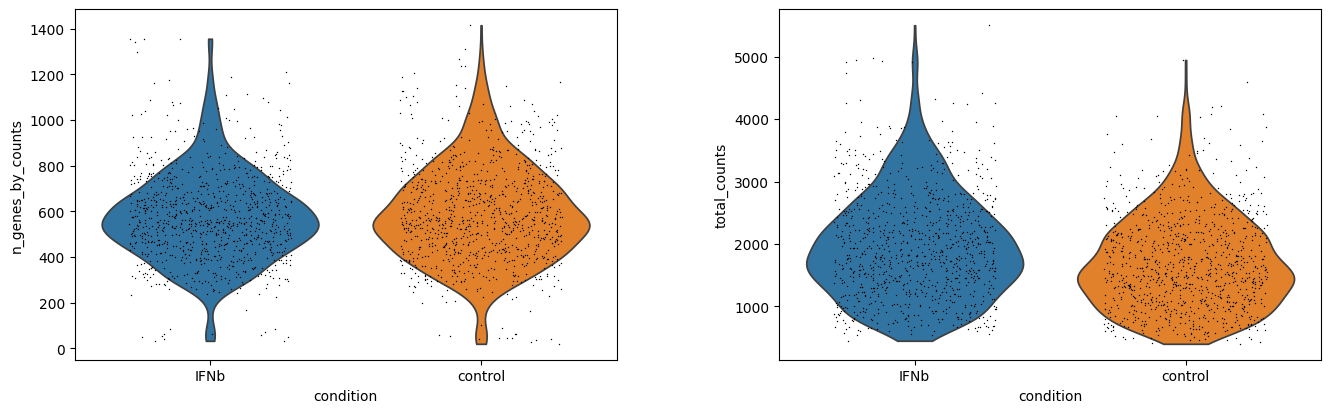

In [6]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    groupby="condition",
    jitter=0.3,
    multi_panel=True,
)

## Snapshot raw counts, then preprocess

Do this **before** HVG / normalize / log1p. PyDESeq2 and Memento need
integers. Enrichment uses the snapshot as the measured-gene background
when you pass `adata=`.


In [7]:
scat.store_raw_counts(adata, layer="counts")

adata_norm = adata.copy()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)

# .X is log1p. Recover integers when a count backend needs them.
adata_counts = scat.restore_raw_counts(adata_norm)
x = adata_counts.X
vals = x.data[:8] if hasattr(x, "data") else np.asarray(x).ravel()[:8]
print("restored .X sample:", vals)
print("n_obs × n_vars:", adata_counts.n_obs, "×", adata_counts.n_vars)

restored .X sample: [170   1   1   2   1   1   2   1]
n_obs × n_vars: 1920 × 8680


## Wilcoxon


In [8]:
adata_norm, de_wilcoxon = scat.differential_expression(
    adata_norm,
    groupby="condition",
    target_group="IFNb",
    reference_group="control",
    de_method="wilcoxon",
    de_preprocess="none",  # we already normalized + log1p'd above
)
de_wilcoxon.sort_values(["p_adj", "logFC"], ascending=[True, False]).head(10)

,logFC,p_val,p_adj,baseMean
ISG15,9.089888,5.207589e-307,4.520187e-303,3.465015
ISG20,6.812402,6.431268e-301,2.791170e-297,2.526995
IFITM3,6.869534,4.420913e-300,1.279118e-296,2.336146
APOBEC3A,7.115931,4.193246e-296,9.099345e-293,2.477201
CXCL10,11.263014,1.463436e-291,2.540524e-288,2.619467
TNFSF10,9.104015,5.874617e-291,8.498612e-288,1.877073
RSAD2,8.830932,3.687798e-286,4.572870e-283,1.855343
IFIT1,9.197159,3.932408e-284,4.266663e-281,1.794139
IDO1,7.522523,5.976569e-264,5.764069e-261,1.843162
IFI6,5.062495,1.368677e-259,1.188012e-256,1.818738


In [9]:
print("min p_adj:", de_wilcoxon["p_adj"].min())
print("genes with p_adj < 0.05:", (de_wilcoxon["p_adj"] < 0.05).sum())

min p_adj: 4.520186861923429e-303
genes with p_adj < 0.05: 975


8 donors per condition: thousands of genes pass `p_adj < 0.05`. Still
apply a `|logFC|` floor before enrichment.


In [10]:
candidates = scat.filter_active_genes(
    de_wilcoxon, select_by="de", padj_cutoff=0.05, logfc_cutoff=1.0
)
print(len(candidates))
candidates.head(10)

338


,logFC,p_val,p_adj,baseMean
ISG15,9.089888,5.207589e-307,4.520187e-303,3.465015
ISG20,6.812402,6.431268e-301,2.791170e-297,2.526995
IFITM3,6.869534,4.420913e-300,1.279118e-296,2.336146
APOBEC3A,7.115931,4.193246e-296,9.099345e-293,2.477201
CXCL10,11.263014,1.463436e-291,2.540524e-288,2.619467
TNFSF10,9.104015,5.874617e-291,8.498612e-288,1.877073
RSAD2,8.830932,3.687798e-286,4.572870e-283,1.855343
IFIT1,9.197159,3.932408e-284,4.266663e-281,1.794139
IDO1,7.522523,5.976569e-264,5.764069e-261,1.843162
IFI6,5.062495,1.368677e-259,1.188012e-256,1.818738


## Pseudobulk + PyDESeq2


In [11]:
adata_pb = adata.copy()  # still cell-level after this call; PB is internal
adata_pb, de_pseudobulk = scat.differential_expression(
    adata_pb,
    groupby="condition",
    target_group="IFNb",
    reference_group="control",
    use_pseudobulk=True,
    sample_col="sample",
    pseudobulk_de_backend="pydeseq2",
)
print("min p_adj (pseudobulk):", de_pseudobulk["p_adj"].min())
print("n p_adj<0.05:", (de_pseudobulk["p_adj"] < 0.05).sum())
de_pseudobulk.sort_values(["p_adj", "logFC"], ascending=[True, False]).head(10)

Fitting dispersions...
... done in 0.02 seconds.

Fitting MAP dispersions...
... done in 0.03 seconds.

Fitting LFCs...
... done in 0.03 seconds.



min p_adj (pseudobulk): 6.276789509911208e-164
n p_adj<0.05: 1872


,logFC,p_val,p_adj,baseMean
IL1RN,6.169660,1.045261e-167,6.276790e-164,300.1250
RSAD2,7.301445,9.528629e-133,2.860971e-129,607.8750
IRF7,3.397571,5.497076e-124,1.100331e-120,257.6250
ISG20,5.529018,6.139973e-123,9.217634e-120,1130.8125
PLSCR1,2.878724,5.741372e-121,6.895388e-118,279.1875
DYNLT1,2.631752,7.531378e-111,7.537654e-108,331.7500
MT2A,5.726250,8.301650e-110,7.121630e-107,163.1875
SAMD9L,3.994489,1.681451e-109,1.262139e-106,131.8125
SSB,3.285564,1.818905e-100,1.213614e-97,137.0625
TMSB10,2.156619,5.145221e-89,3.089705e-86,984.7500


In [12]:
up_pb = scat.filter_active_genes(de_pseudobulk, select_by="de", padj_cutoff=0.05, logfc_cutoff=1.0)
shared = candidates.index.intersection(up_pb.index)
print(
    f"DE genes (p_adj<0.05, logFC>1): Wilcoxon {len(candidates)}, "
    f"PyDESeq2 {len(up_pb)}, overlap {len(shared)}"
)

DE genes (p_adj<0.05, logFC>1): Wilcoxon 338, PyDESeq2 759, overlap 337


## Memento


In [13]:
adata_mem = adata.copy()
adata_mem, de_memento = scat.differential_expression(
    adata_mem,
    groupby="condition",
    target_group="IFNb",
    reference_group="control",
    use_memento_de=True,
)
de_memento.sort_values(["p_adj", "logFC"], ascending=[True, False]).head(10)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.


[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    1.5s


[Parallel(n_jobs=-1)]: Done 244 tasks      | elapsed:    3.3s


[Parallel(n_jobs=-1)]: Done 744 tasks      | elapsed:    7.4s


[Parallel(n_jobs=-1)]: Done 1444 tasks      | elapsed:   12.9s


[Parallel(n_jobs=-1)]: Done 1552 out of 1552 | elapsed:   14.1s finished


,logFC,p_val,p_adj,memento_de_se,memento_dv_coef,memento_dv_se,memento_dv_pval,baseMean
ISG15,7.101491,0.000000e+00,0.000000e+00,0.115062,-4.305560,0.138791,1.366309e-211,57.918229
APOBEC3A,5.692846,0.000000e+00,0.000000e+00,0.093716,-2.334758,0.156924,2.344423e-50,10.776563
IFI6,4.060311,0.000000e+00,0.000000e+00,0.074531,-1.834193,0.184622,1.783293e-23,2.851042
TMSB10,2.026469,0.000000e+00,0.000000e+00,0.028827,-1.082626,0.124958,2.686751e-18,8.206250
DYNLT1,2.481093,3.664299e-303,1.137398e-300,0.046227,-0.849590,0.384416,2.188022e-02,2.764583
ISG20,5.250323,1.366814e-301,3.535493e-299,0.097894,-3.393408,0.232030,9.767908e-49,9.423438
IFITM3,5.308488,2.150983e-294,4.769038e-292,0.100170,-3.584216,0.223486,3.490512e-58,7.180208
TYMP,1.500108,1.198195e-255,2.324499e-253,0.030409,-0.389241,0.120539,8.740180e-04,6.078646
FTH1,-0.958211,9.330584e-254,1.609007e-251,0.019492,0.541024,0.080376,2.079416e-11,73.047396
MYL12A,1.750222,2.238374e-246,3.473957e-244,0.036202,-0.550316,0.189429,2.831860e-03,3.786979


## MixedLM

Eight donors (≥4 samples/group). `logFC` is the sample-mean-of-means
log2FC; `p_adj` tests the LMM fixed effect. Do not combine with
`use_memento_de`. Some genes emit a singular random-effects warning;
that is a statsmodels fit note, not a crash.


In [14]:
import warnings

# scatrans deliberately does NOT suppress this warning for real analyses (see
# _DE_SUPPRESS_WARNING_CATEGORIES in _de.py) — it is the caller's signal that
# some genes hit a boundary/singular random-effects fit. On a genome-wide run
# it repeats per gene (thousands of times here), so we scope the suppression
# to just this tutorial cell rather than hiding it from real usage.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*[Rr]andom effects covariance.*")
    adata_mm, de_mixed = scat.differential_expression(
        adata_norm.copy(),
        groupby="condition",
        target_group="IFNb",
        reference_group="control",
        use_mixed_model=True,
        sample_col="sample",
        de_preprocess="none",
    )
print("logFC_method:", de_mixed.attrs.get("logFC_method"))
up_mm = scat.filter_active_genes(de_mixed, select_by="de", padj_cutoff=0.05, logfc_cutoff=1.0)
print("DE genes (p_adj<0.05, logFC>1):", len(up_mm))
de_mixed.sort_values(["p_adj", "logFC"], ascending=[True, False]).head(10)

logFC_method: sample_mean_of_means_log2
DE genes (p_adj<0.05, logFC>1): 382


,logFC,p_val,p_adj,mixedlm_coef,delta_variance,delta_var_pval,baseMean
CXCL10,11.263014,0.000000e+00,0.000000e+00,5.101402,0.840840,2.546684e-18,2.619467
IFIT1,9.197158,0.000000e+00,0.000000e+00,3.478130,0.844442,6.466298e-20,1.794139
TNFSF10,9.104016,0.000000e+00,0.000000e+00,3.617605,0.859559,7.135453e-19,1.877073
ISG15,9.089888,0.000000e+00,0.000000e+00,5.587189,0.881146,1.368843e-17,3.465015
RSAD2,8.830932,0.000000e+00,0.000000e+00,3.555165,0.844923,6.585601e-19,1.855343
ISG20,6.812402,0.000000e+00,0.000000e+00,3.905367,0.825014,3.530982e-18,2.526995
MT2A,6.549226,0.000000e+00,0.000000e+00,2.094832,0.559693,1.493585e-17,1.127424
IL1RN,7.308311,1.764915e-276,1.914933e-273,2.586634,0.622919,5.661907e-17,1.374529
IRF7,3.898301,3.564514e-225,3.437776e-222,2.052415,0.501478,3.534343e-16,1.695377
IFI35,4.426356,6.033859e-211,5.237390e-208,1.802614,0.479105,1.095277e-15,1.185104


Compare DE-gated lists (`p_adj` + `|logFC|`), not the largest raw logFC —
sparse genes inflate fold-change. On this object the Wilcoxon and
PyDESeq2 up-lists overlap 337 / 338. Use `select_by="de"` for
enrichment. Down-regulated genes use the same gates with
`logfc_direction="down"`.

## Enrichment


In [15]:
candidate_genes = candidates.index.tolist()
down = scat.filter_active_genes(
    de_wilcoxon,
    select_by="de",
    padj_cutoff=0.05,
    logfc_cutoff=1.0,
    logfc_direction="down",
)
down_genes = down.index.tolist()
len(candidate_genes), len(down_genes)

(338, 371)

### GO Biological Process


In [16]:
go_res = scat.run_enrichment(
    candidate_genes,
    gene_sets="GO_Biological_Process",
    organism="human",
    adata=adata_norm,  # auto-supplies the stored measured-gene background
    return_all=True,
)
print(
    f"{len(go_res)} GO BP terms tested, {(go_res['p.adjust'] < 0.05).sum()} significant at p.adjust<0.05"
)
go_res.sort_values("p.adjust").head(10)[["Term", "Count", "GeneRatio", "pvalue", "p.adjust"]]

5949 GO BP terms tested, 311 significant at p.adjust<0.05


,Term,Count,GeneRatio,pvalue,p.adjust
0,response to peptide (GO:1901652),84,0.264151,3.814881e-31,7.564910e-28
1,response to cytokine (GO:0034097),84,0.264151,1.763400e-31,7.564910e-28
2,defense response to virus (GO:0051607),56,0.176101,2.781547e-31,7.564910e-28
3,response to virus (GO:0009615),62,0.194969,2.353383e-30,3.500068e-27
4,cellular response to cytokine stimulus (GO:007...,67,0.210692,1.817758e-22,2.162768e-19
5,response to type II interferon (GO:0034341),30,0.094340,1.037422e-21,1.028604e-18
6,negative regulation of viral genome replicatio...,20,0.062893,1.928451e-18,1.638908e-15
7,regulation of response to biotic stimulus (GO:...,57,0.179245,3.071294e-18,2.283891e-15
8,viral process (GO:0016032),45,0.141509,2.569108e-17,1.698180e-14
9,cytokine-mediated signaling pathway (GO:0019221),48,0.150943,3.043458e-17,1.810553e-14


Top terms are cytokine / antiviral / type-II interferon response.

### KEGG


In [17]:
kegg_res = scat.run_kegg(
    candidate_genes,
    organism="human",
    adata=adata_norm,
    return_all=True,
)
kegg_res.sort_values("p.adjust").head(10)[["Term", "Count", "pvalue", "p.adjust"]]

,Term,Count,pvalue,p.adjust
0,Cytokine-cytokine receptor interaction(hsa04060),16,0.000023,0.004731
1,Chemokine signaling pathway(hsa04062),16,0.000126,0.013082
2,Antigen processing and presentation(hsa04612),9,0.000513,0.035407
3,Cytosolic DNA-sensing pathway(hsa04623),7,0.000789,0.040818
4,Nicotinate and nicotinamide metabolism(hsa00760),4,0.002663,0.110240
5,Toll-like receptor signaling pathway(hsa04620),9,0.005838,0.201408
6,Rheumatoid arthritis(hsa05323),7,0.015407,0.367807
7,RIG-I-like receptor signaling pathway(hsa04622),6,0.017768,0.367807
9,Hepatitis C(hsa05160),9,0.013813,0.367807
8,Cell adhesion molecule (CAM) interaction(hsa04...,7,0.016916,0.367807


Cytokine–receptor and chemokine pathways sit at the top, consistent with
the GO table.

### GO, all three ontologies (`ontology="ALL"`)


In [18]:
go_all = scat.run_go(
    candidate_genes,
    ontology="ALL",
    organism="human",
    adata=adata_norm,
    return_all=True,
    adjust_across_all=True,  # single BH correction across BP+CC+MF combined
)
print("ontologies covered:", list(go_all.attrs["per_ontology_attrs"].keys()))
go_all.sort_values("p.adjust").head(6)[["Term", "Count", "pvalue", "p.adjust"]]

ontologies covered: ['BP', 'CC', 'MF']


,Term,Count,pvalue,p.adjust
0,response to peptide (GO:1901652),84,3.814881e-31,7.564910e-28
1,response to cytokine (GO:0034097),84,1.763400e-31,7.564910e-28
2,defense response to virus (GO:0051607),56,2.781547e-31,7.564910e-28
3,response to virus (GO:0009615),62,2.353383e-30,3.500068e-27
4,cellular response to cytokine stimulus (GO:007...,67,1.817758e-22,2.162768e-19
5,response to type II interferon (GO:0034341),30,1.037422e-21,1.028604e-18


### Pre-ranked GSEA


In [19]:
ranked = de_wilcoxon["logFC"].sort_values(ascending=False)
gsea_res = scat.run_gsea(
    ranked_genes=ranked,
    gene_sets="GO_Biological_Process",
    organism="human",
    nperm=100,  # tutorial speed; use 1000 in a paper
    min_size=15,
)
gsea_res.sort_values("p.adjust")[["Term", "NES", "pvalue", "p.adjust", "leading_edge"]].head(10)

2026-08-26 10:38:01,250 [WARNING] Duplicated values found in preranked stats: 0.90% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,pvalue,p.adjust,leading_edge
4,regulatory T cell differentiation (GO:0045066),2.021892,0.0,0.005426,LAG3;KAT2A;MDK;SOCS1;IL4I1;PSMB9;PSMA4;FANCA;I...
3,negative regulation of viral process (GO:0048525),2.022270,0.0,0.006782,CH25H;APOBEC3H;TRIM14;IFIT1;ISG15;RSAD2;APOBEC...
5,regulation of regulatory T cell differentiatio...,1.993952,0.0,0.006782,LAG3;KAT2A;MDK;SOCS1;IL4I1;PSMB9;PSMA4;FANCA;I...
2,negative regulation of viral genome replicatio...,2.035130,0.0,0.009043,APOBEC3H;IFIT1;ISG15;RSAD2;APOBEC3A;IFITM3;ISG...
6,T-helper 1 cell differentiation (GO:0045063),1.975791,0.0,0.009689,IL18RAP;IL18R1;IL27;CD80;PSMB9;PSMA4;ASCL2
1,response to type II interferon (GO:0034341),2.038790,0.0,0.013565,EDN1;TXK;IFITM3;ACOD1;IFITM1;IFITM2;CCL2;GBP4;...
8,interferon-mediated signaling pathway (GO:0140...,1.934989,0.0,0.015072,ZBP1;USP18;TXK;ISG15;IFITM3;IFITM1;OAS2;OAS3;I...
7,response to type I interferon (GO:0034340),1.944836,0.0,0.016956,ZBP1;USP18;CH25H;IFIT1;ISG15;IFITM3;MX1;IFITM1...
10,regulation of immune effector process (GO:0002...,1.905706,0.0,0.019730,LAG3;TNFSF18;IL6;STAP1;IL18R1;SLAMF6;XCL1;RSAD...
9,type I interferon-mediated signaling pathway (...,1.905964,0.0,0.021704,ZBP1;USP18;ISG15;IFITM3;IFITM1;OAS2;OAS3;IFITM...


`gseaplot` and `enrich_dotplot(..., x="NES")` below. `nperm=100` is for
speed (p-values floor at `1/nperm`). Use 1000 for a paper.


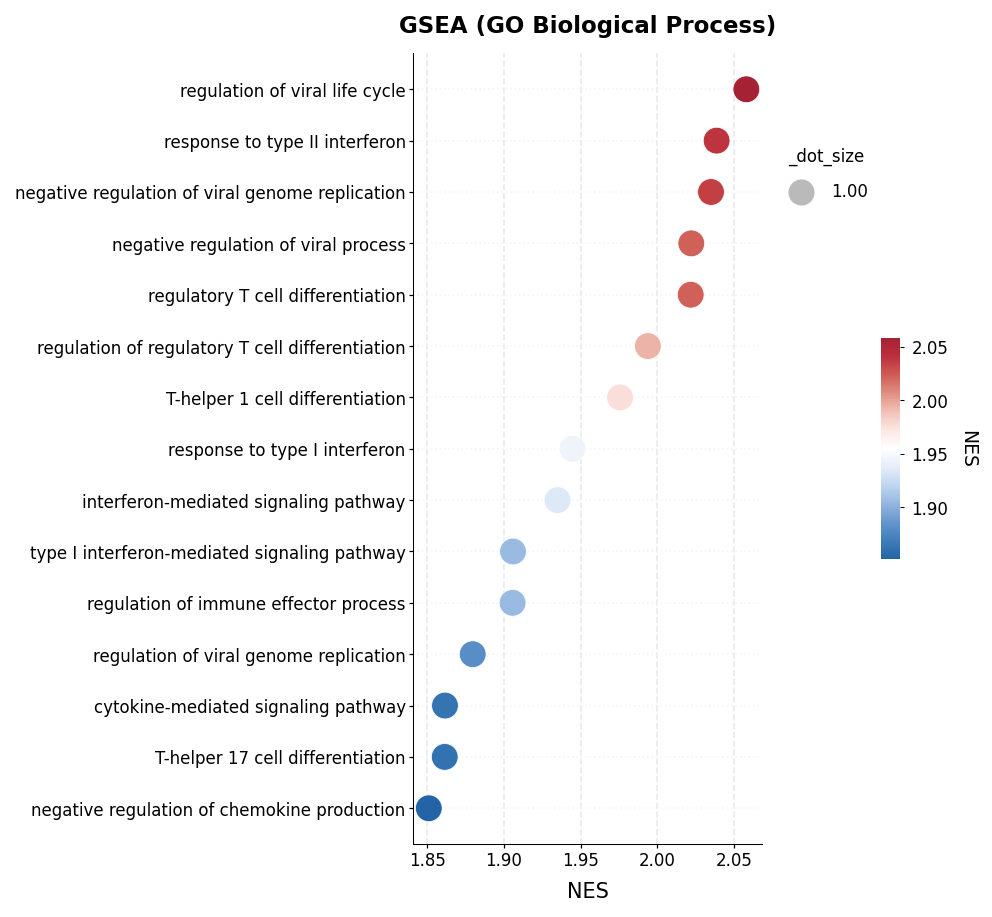

In [20]:
scat.pl.enrich_dotplot(
    gsea_res, top_n=15, x="NES", color_by="NES", title="GSEA (GO Biological Process)"
);

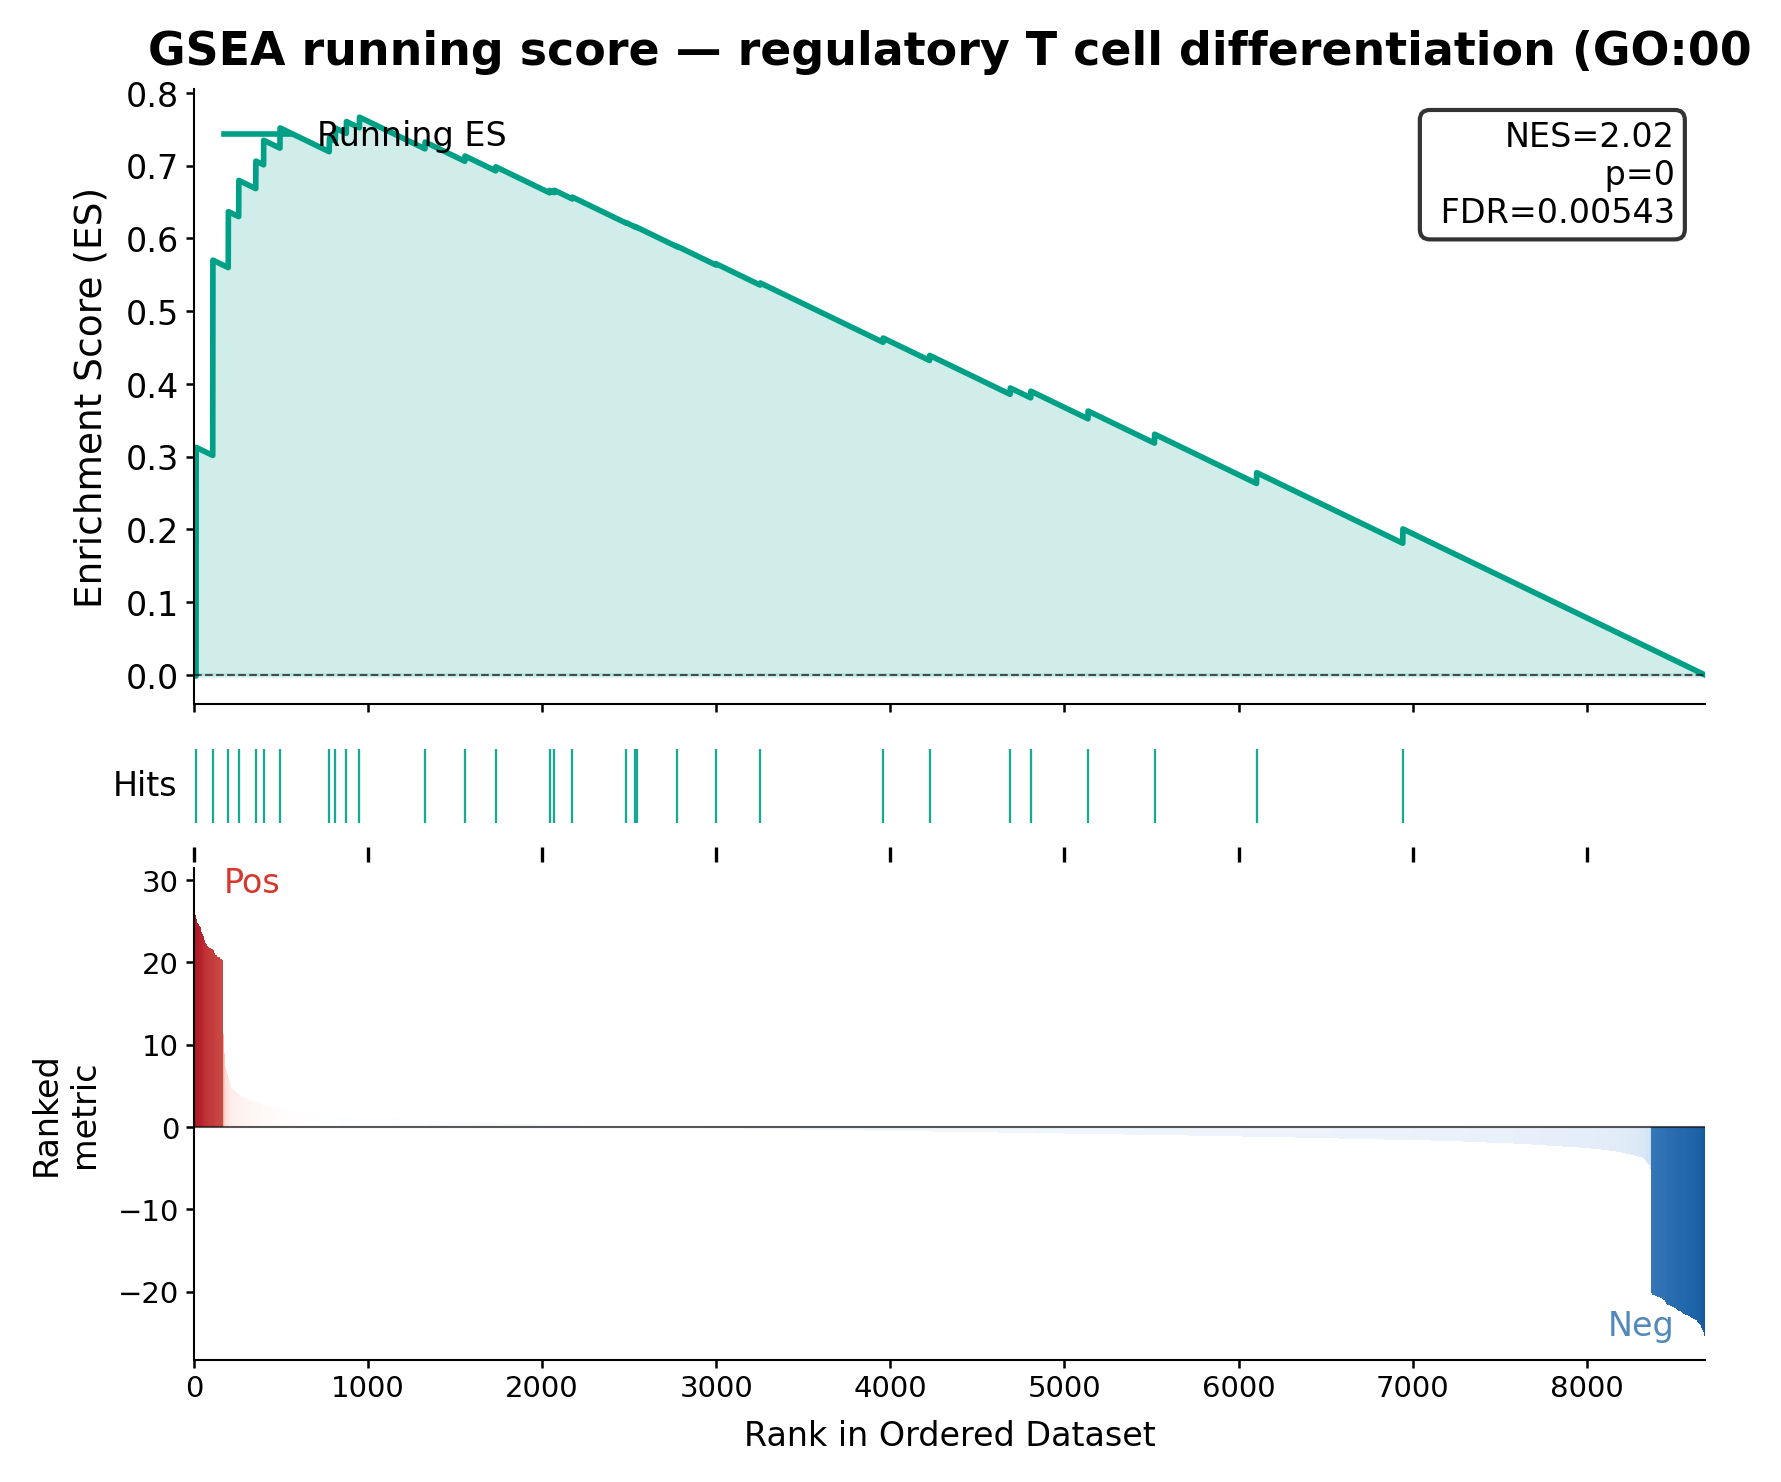

In [21]:
top_term = gsea_res.sort_values("p.adjust").iloc[0]["Term"]
scat.pl.gseaplot(ranked, gsea_res, term=top_term, title=f"GSEA running score — {top_term[:40]}");

### `simplify_enrichment`


In [22]:
go_sig = go_res[go_res["p.adjust"] < 0.05].copy()
print("significant GO BP terms before simplify:", len(go_sig))

simplified_jaccard = scat.simplify_enrichment(
    go_sig,
    method="jaccard",
    similarity_cutoff=0.5,
    min_count=3,
)
print(f"jaccard: {len(go_sig)} -> {len(simplified_jaccard)} terms")

simplified_denester = scat.simplify_enrichment(
    go_sig,
    method="pathway_denester",
    min_count=3,
)
print(f"pathway_denester: {len(go_sig)} -> {len(simplified_denester)} terms")

significant GO BP terms before simplify: 311
jaccard: 311 -> 99 terms


pathway_denester: 311 -> 105 terms


What actually happens to a specific redundant pair — `jaccard` keeps
one representative per similarity cluster and drops the rest, even when the
dropped term was individually more significant:

In [23]:
kept = set(simplified_jaccard["Term"])
dropped = go_sig[~go_sig["Term"].isin(kept)].sort_values("p.adjust")
print("most significant term that got folded away:")
print(dropped[["Term", "Count", "p.adjust"]].head(3))
print("\nkept as its representative:")
print(simplified_jaccard.sort_values("p.adjust")[["Term", "Count", "p.adjust"]].head(3))

most significant term that got folded away:
                                                Term  Count      p.adjust
1                  response to cytokine (GO:0034097)     84  7.564910e-28
3                     response to virus (GO:0009615)     62  3.500068e-27
4  cellular response to cytokine stimulus (GO:007...     67  2.162768e-19

kept as its representative:
                                          Term  Count      p.adjust
0             response to peptide (GO:1901652)     84  7.564910e-28
1       defense response to virus (GO:0051607)     56  7.564910e-28
2  response to type II interferon (GO:0034341)     30  1.028604e-18


The raw significant-term dotplot is a stack of near-duplicate viral-response
rows. After simplify, one representative per cluster remains.

`color_by="neg_log10_padj"` instead of `"p.adjust"`: with this many tiny
p-values the linear padj scale collapses to one color.


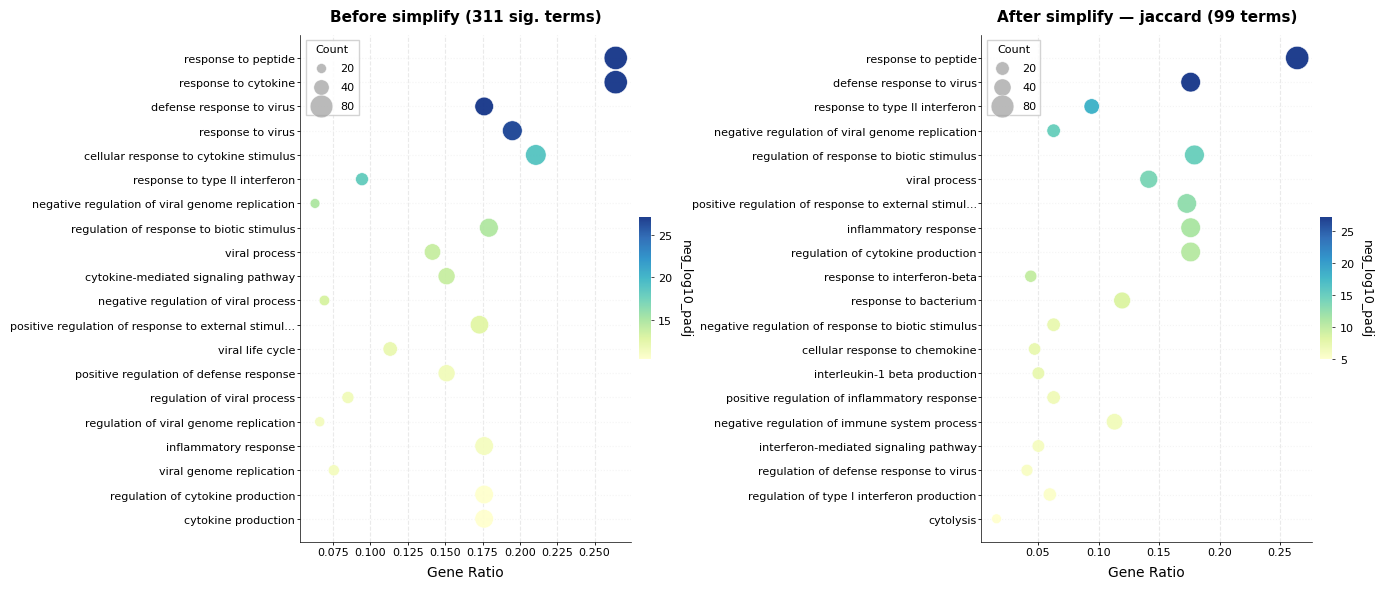

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scat.pl.enrich_dotplot(
    go_sig,
    top_n=20,
    title=f"Before simplify ({len(go_sig)} sig. terms)",
    ax=axes[0],
    color_by="neg_log10_padj",
)
scat.pl.enrich_dotplot(
    simplified_jaccard,
    top_n=20,
    title=f"After simplify — jaccard ({len(simplified_jaccard)} terms)",
    ax=axes[1],
    color_by="neg_log10_padj",
)
plt.tight_layout()

### `compare_enrichment` across cell types


In [25]:
cd4 = adata_full[adata_full.obs["celltype"] == "CD4 T cells"].copy()
scat.store_raw_counts(cd4, layer="counts")
cd4_norm = cd4.copy()
sc.pp.normalize_total(cd4_norm, target_sum=1e4)
sc.pp.log1p(cd4_norm)

cd4_norm, de_cd4 = scat.differential_expression(
    cd4_norm,
    groupby="condition",
    target_group="IFNb",
    reference_group="control",
    de_method="wilcoxon",
    de_preprocess="none",
)
candidates_cd4 = scat.filter_active_genes(
    de_cd4, select_by="de", padj_cutoff=0.05, logfc_cutoff=1.0
)
candidate_genes_cd4 = candidates_cd4.index.tolist()
print(
    "Monocyte candidates:", len(candidate_genes), " |  CD4 T candidates:", len(candidate_genes_cd4)
)

Monocyte candidates: 338  |  CD4 T candidates: 99


Monocytes respond more strongly than CD4 T cells, as in Kang et al.


In [26]:
cmp_res = scat.compare_enrichment(
    {"Monocyte": candidate_genes, "CD4T": candidate_genes_cd4},
    organism="human",
    gene_sets="GO_Biological_Process",
    adata=adata_norm,
)
cmp_res["Cluster"].value_counts()

Cluster
Monocyte    311
CD4T        129
Name: count, dtype: int64

`concat_compare_results` does the same reshaping when you already have
separate result tables in hand (e.g. combining our GO and KEGG results
above into one comparable table, for the Monocyte cluster):

In [27]:
concat_res = scat.concat_compare_results({"GO": go_res, "KEGG": kegg_res})
concat_res["Cluster"].value_counts()

Cluster
GO      5949
KEGG     207
Name: count, dtype: int64

### `compare_de_across_groups` (new in 0.10.16)

The Monocyte-vs-CD4T comparison above ran `differential_expression` by hand
for each `celltype`. `compare_de_across_groups` does the same loop in one
call — run it directly on `adata_full` (both cell types, not yet subset) and
it reproduces the `candidate_genes` / `candidate_genes_cd4` counts above.

                  up  down  total
group                            
CD14+ Monocytes  338   371    709
CD4 T cells       99    13    112
failed: {}


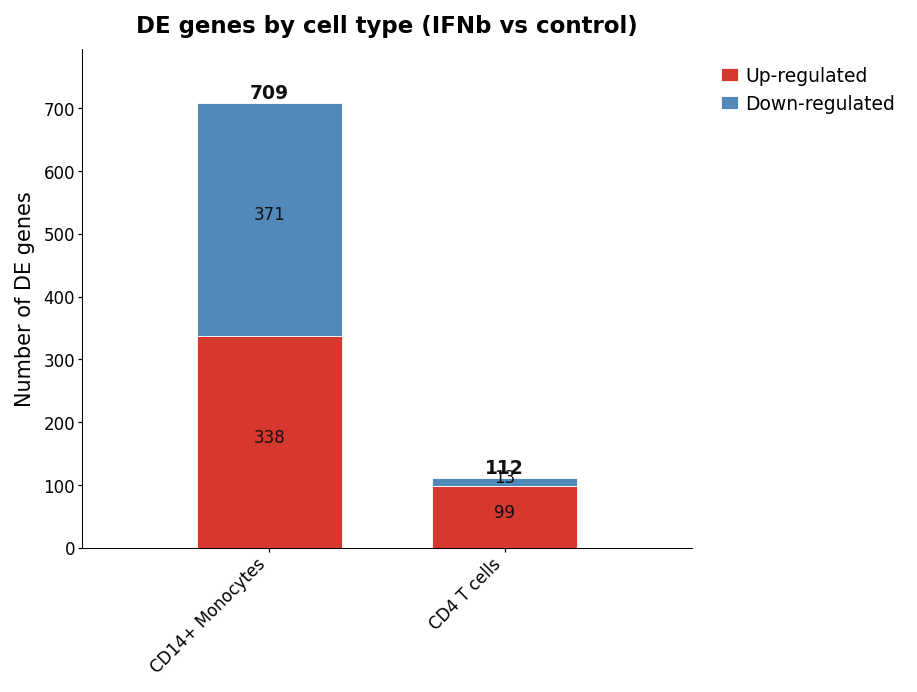

In [28]:
cmp = scat.compare_de_across_groups(
    adata_full,
    split_by="celltype",
    groupby="condition",
    target_group="IFNb",
    reference_group="control",
    de_kwargs={"de_method": "wilcoxon"},
    padj_cutoff=0.05,
    logfc_cutoff=1.0,
)
print(cmp.summary)
print("failed:", cmp.failed)

scat.pl.de_summary_barplot(
    cmp, mode="stacked", sort_by="total", title="DE genes by cell type (IFNb vs control)"
);

`pl.group_stat_plot` makes the "Monocytes respond more strongly" observation
quantitative: compare `logFC` (restricted to genes called up in either cell
type) between the two `cmp.results` tables, with a Mann-Whitney significance
bracket.

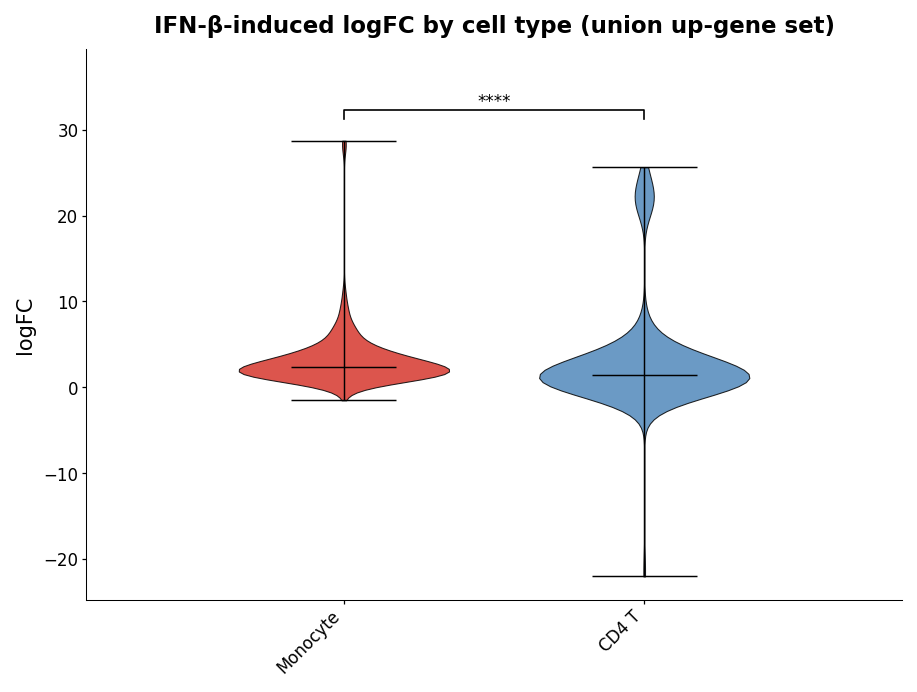

In [29]:
import pandas as pd

up_union = sorted(set(cmp.up["CD14+ Monocytes"].index) | set(cmp.up["CD4 T cells"].index))
stat_df = pd.concat(
    [
        cmp.results["CD14+ Monocytes"].loc[up_union].assign(celltype="Monocyte"),
        cmp.results["CD4 T cells"].loc[up_union].assign(celltype="CD4 T"),
    ]
)
scat.pl.group_stat_plot(
    stat_df,
    value_col="logFC",
    groupby="celltype",
    kind="violin",
    comparisons=[("Monocyte", "CD4 T")],
    title="IFN-β-induced logFC by cell type (union up-gene set)",
);

### Export


In [30]:
import os
import tempfile

tmpdir = tempfile.mkdtemp()
saved_paths = scat.save_enrichment_report(
    kegg_res,
    prefix=os.path.join(tmpdir, "kegg_demo"),
    save_excel=True,
    save_csv=True,
    save_tsv=True,
    save_metadata=True,
    save_term_gene_table=True,
)
saved_paths

{'results_csv': '/tmp/tmp3nxq0nwx/kegg_demo_results.csv',
 'term_gene_table_csv': '/tmp/tmp3nxq0nwx/kegg_demo_term_gene_table.csv',
 'results_tsv': '/tmp/tmp3nxq0nwx/kegg_demo_results.tsv',
 'term_gene_table_tsv': '/tmp/tmp3nxq0nwx/kegg_demo_term_gene_table.tsv',
 'metadata_json': '/tmp/tmp3nxq0nwx/kegg_demo_metadata.json',
 'results_xlsx': '/tmp/tmp3nxq0nwx/kegg_demo_results.xlsx'}

In [31]:
long_table = scat.expand_enrichment_genes(kegg_res)
print(long_table.shape)
long_table.head()

(351, 14)


,Term,Description,Gene,Count,GeneRatio,GeneRatio_str,BgRatio,BgRatio_str,FoldEnrichment,RichFactor,Overlap,pvalue,p.adjust,TermSize
0,Cytokine-cytokine receptor interaction(hsa04060),,CCL2,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103
1,Cytokine-cytokine receptor interaction(hsa04060),,CCL3,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103
2,Cytokine-cytokine receptor interaction(hsa04060),,CCL3L3,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103
3,Cytokine-cytokine receptor interaction(hsa04060),,CCL4,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103
4,Cytokine-cytokine receptor interaction(hsa04060),,CCL4L2,16,0.115108,16/139,0.035839,103/2874,3.211846,0.15534,16/103,0.000023,0.004731,103


## Plots


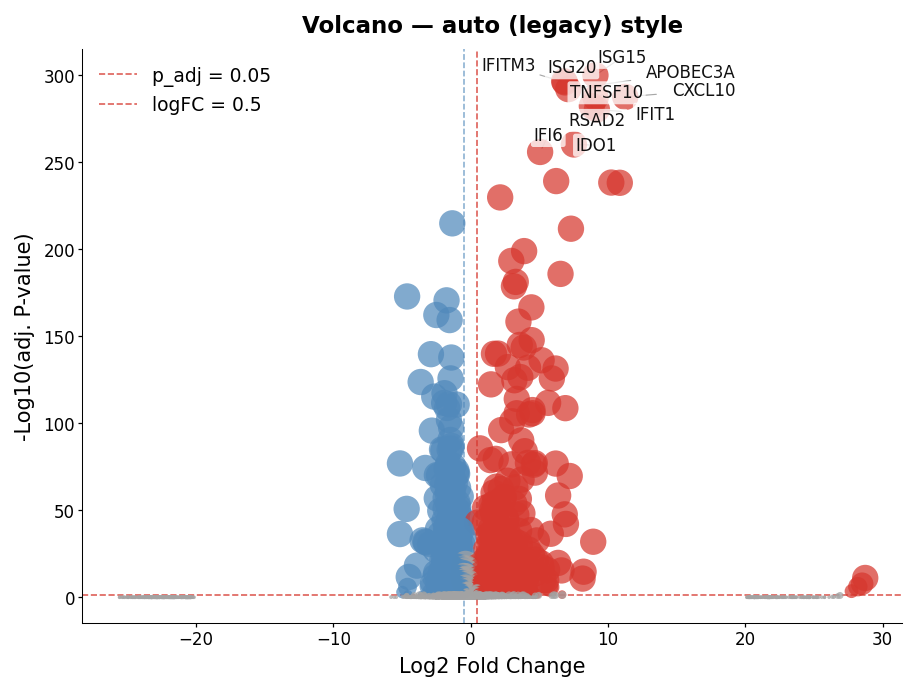

In [32]:
scat.pl.volcano_plot(de_wilcoxon, style="auto", top_n=10, title="Volcano — auto (legacy) style");

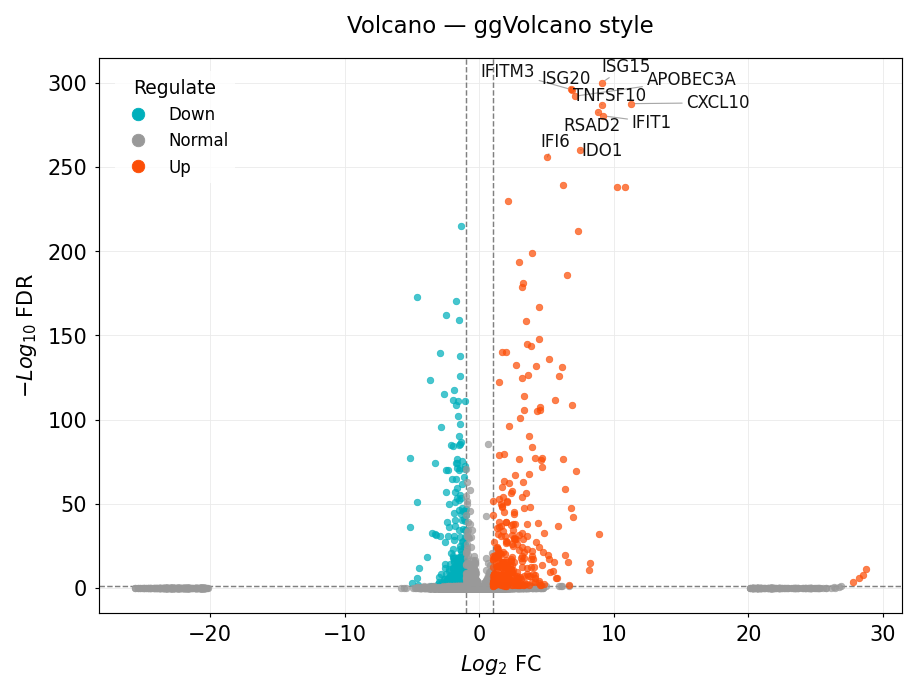

In [33]:
scat.pl.volcano_plot(
    de_wilcoxon,
    style="ggvolcano",
    top_n=10,
    logfc_cutoff=1.0,
    pval_cutoff=0.05,
    title="Volcano — ggVolcano style",
);

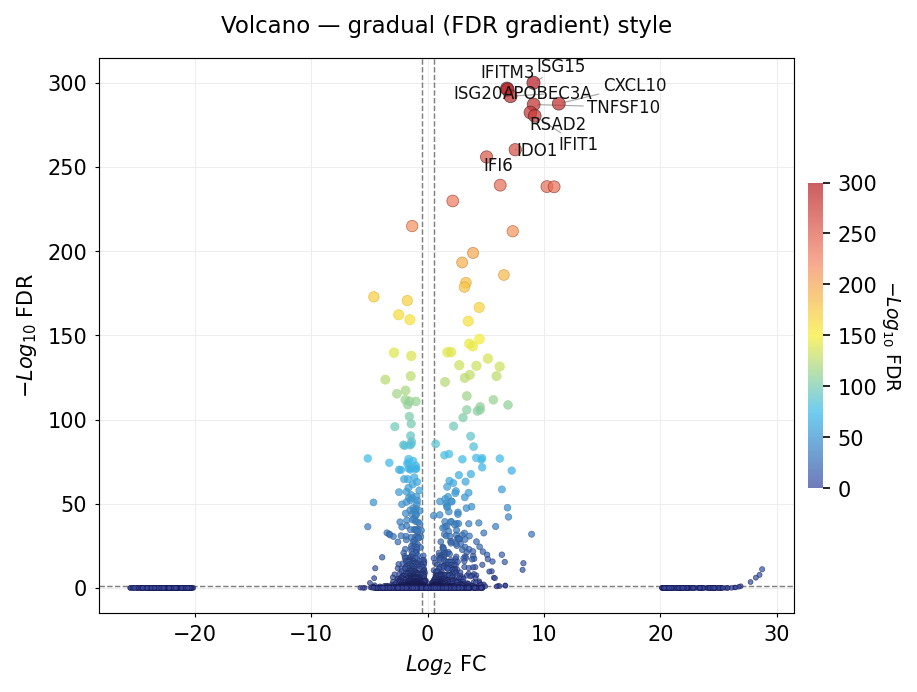

In [34]:
scat.pl.volcano_plot(
    de_wilcoxon, style="gradual", top_n=10, title="Volcano — gradual (FDR gradient) style"
);

### Enrichment dots and bars


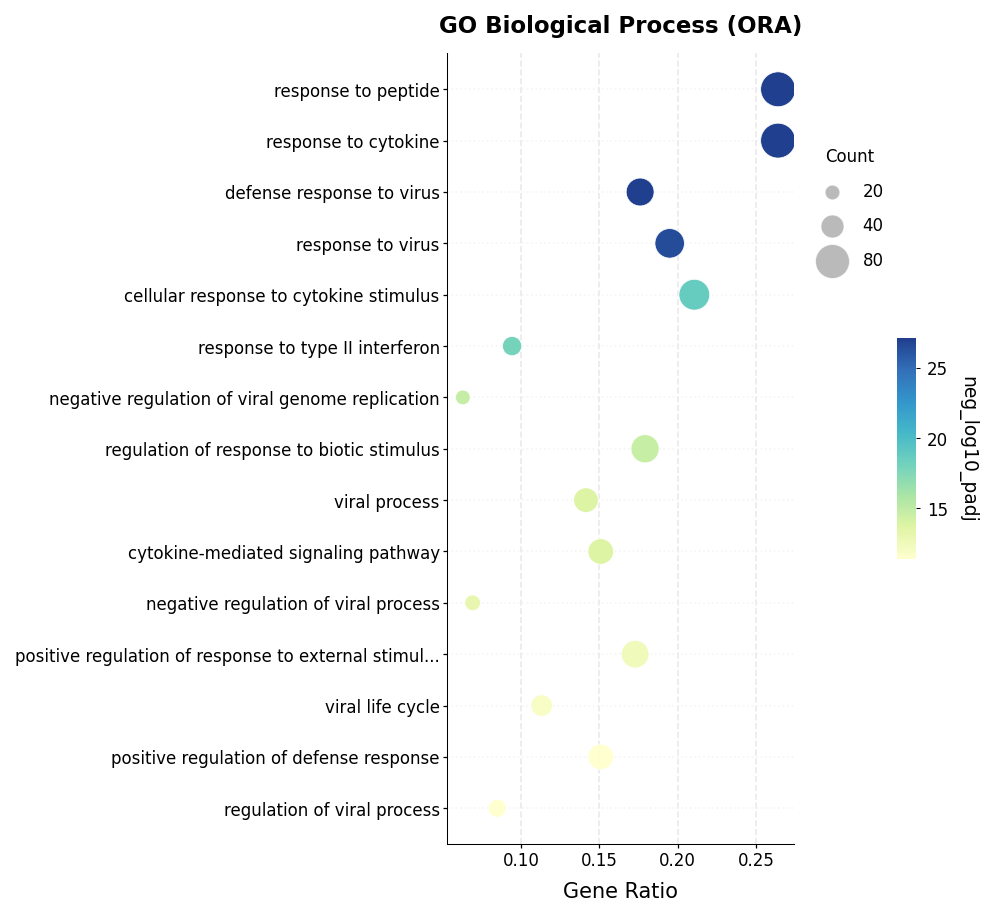

In [35]:
scat.pl.enrich_dotplot(
    go_res, top_n=15, title="GO Biological Process (ORA)", color_by="neg_log10_padj"
);

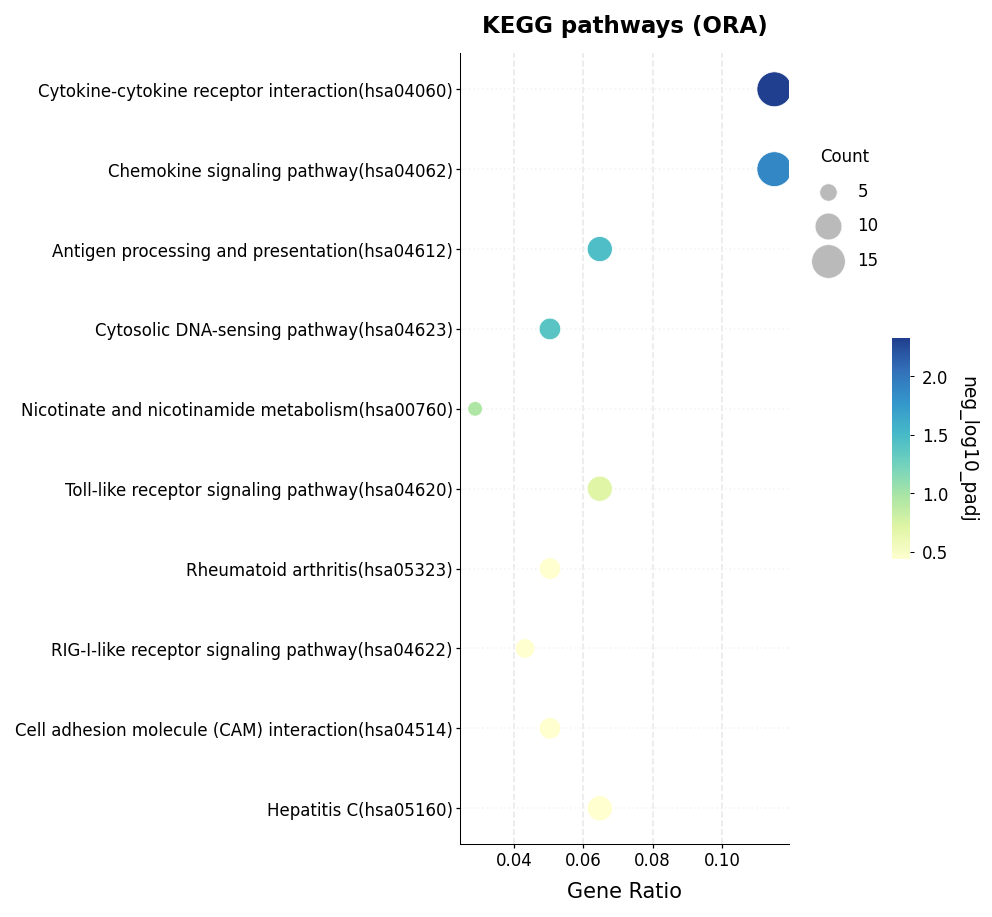

In [36]:
scat.pl.enrich_dotplot(kegg_res, top_n=10, title="KEGG pathways (ORA)", color_by="neg_log10_padj");

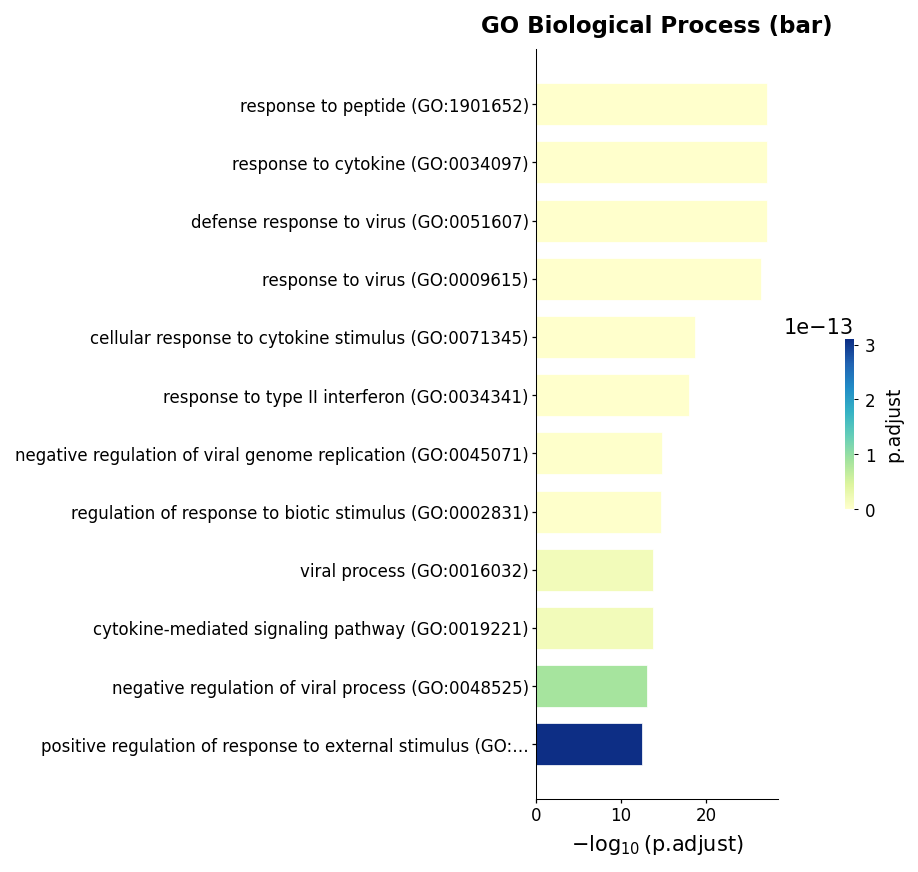

In [37]:
scat.pl.enrich_barplot(go_res, top_n=12, title="GO Biological Process (bar)");

### compareCluster-style grid


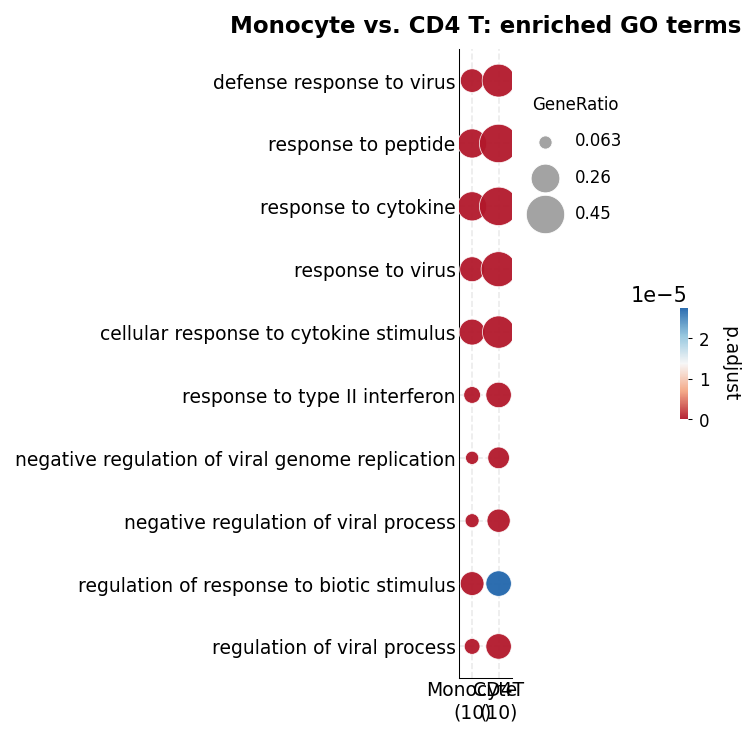

In [38]:
scat.pl.compare_dotplot(
    cmp_res,  # Monocyte vs. CD4T (Cluster column = cell type)
    top_n=8,
    title="Monocyte vs. CD4 T: enriched GO terms",
);

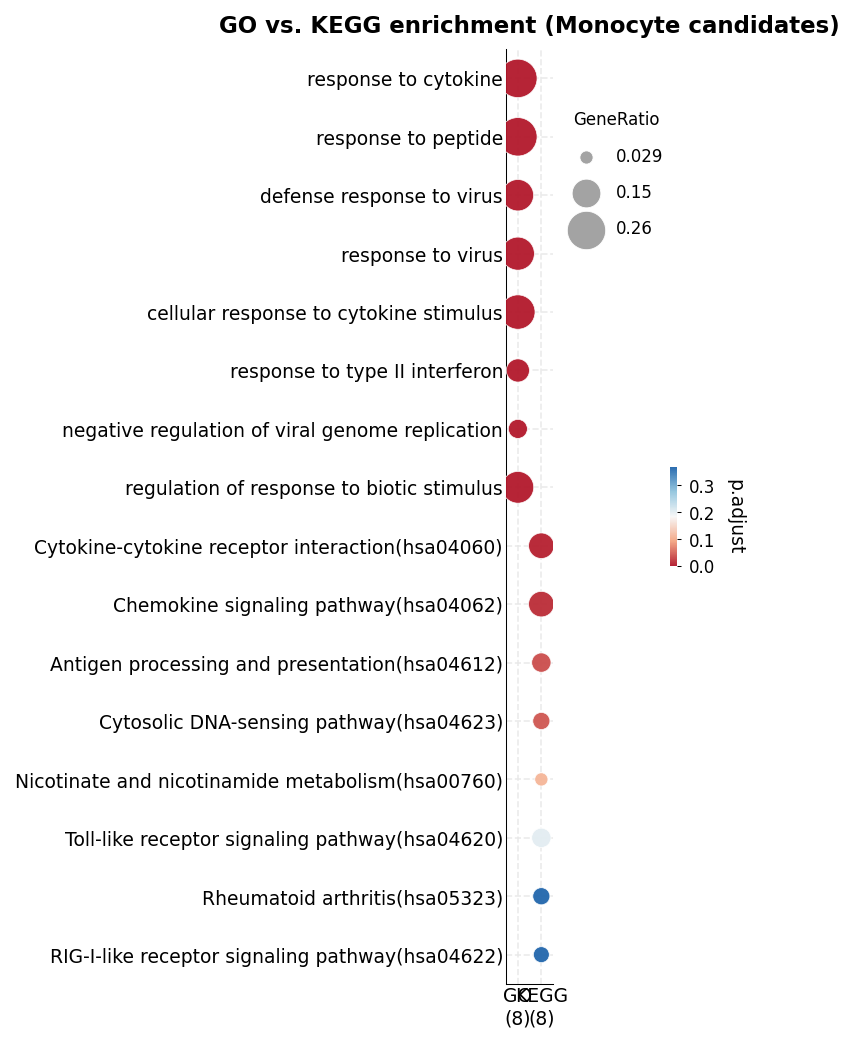

In [39]:
scat.pl.compare_dotplot(
    concat_res,  # GO + KEGG combined (Cluster column = GO / KEGG)
    top_n=8,
    title="GO vs. KEGG enrichment (Monocyte candidates)",
);

### UpSet and Venn


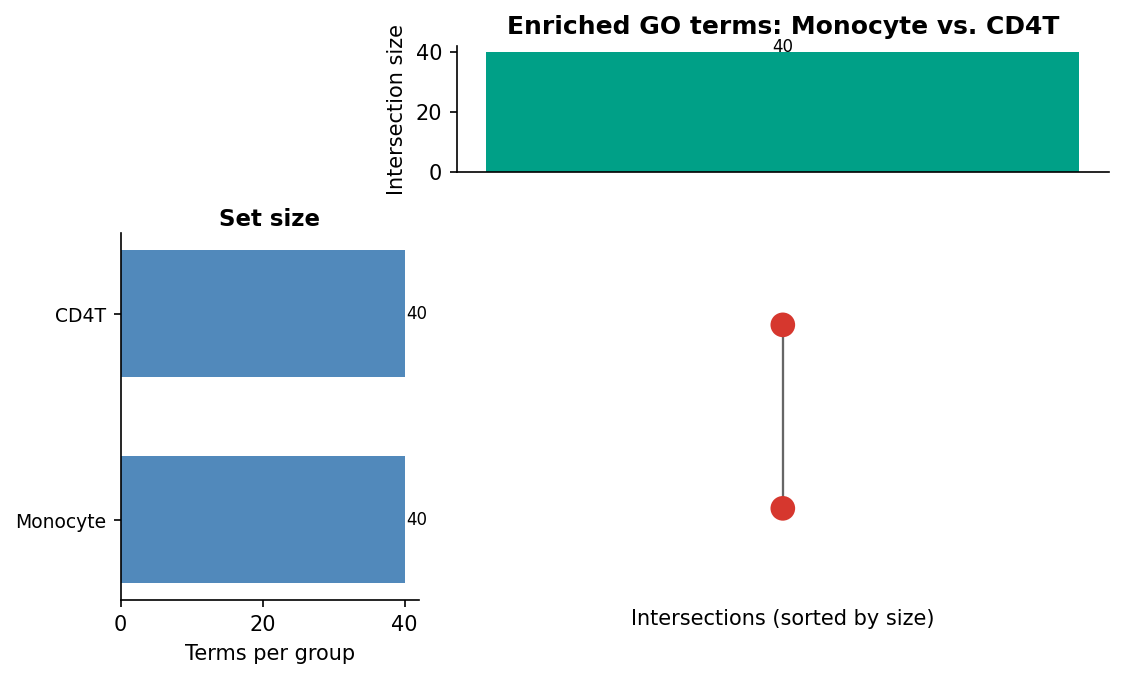

In [40]:
scat.pl.enrich_upsetplot(cmp_res, pval_cutoff=0.05, title="Enriched GO terms: Monocyte vs. CD4T");

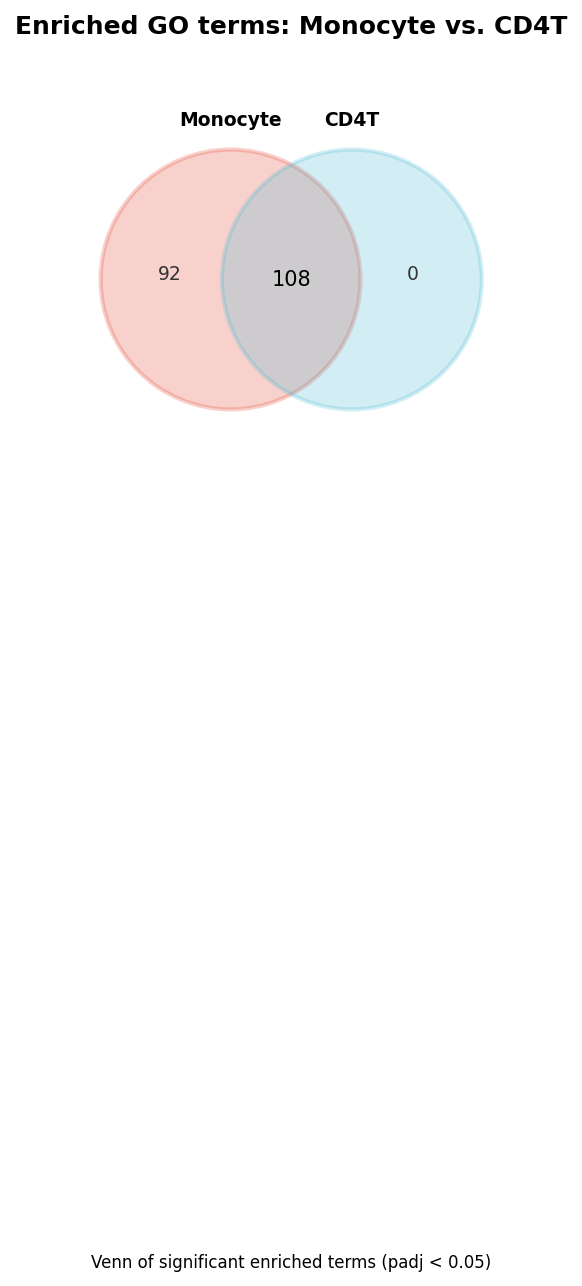

In [41]:
scat.pl.enrich_vennplot(cmp_res, pval_cutoff=0.05, title="Enriched GO terms: Monocyte vs. CD4T");

### Enrichment map (`enrich_network_plot`, new in 0.10.16)

The redundant viral-response GO terms that `simplify_enrichment` collapses
above are exactly the kind of structure an enrichment map makes visible:
terms sharing many genes cluster together. Left: the 311 raw significant
terms (`go_sig`) — expect one dense, mostly-connected clump. Right: after
`simplify_enrichment`, fewer nodes and a sparser graph.

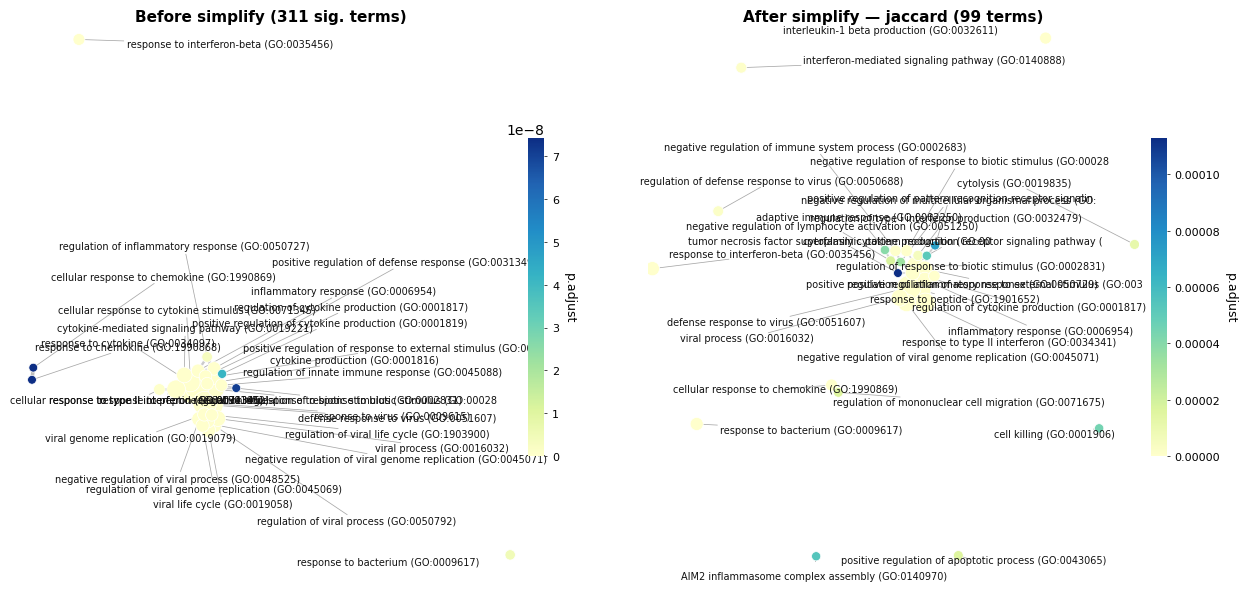

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
scat.pl.enrich_network_plot(
    go_sig,
    top_n=30,
    min_similarity=0.3,
    title=f"Before simplify ({len(go_sig)} sig. terms)",
    ax=axes[0],
    show=False,
)
scat.pl.enrich_network_plot(
    simplified_jaccard,
    top_n=30,
    min_similarity=0.3,
    title=f"After simplify — jaccard ({len(simplified_jaccard)} terms)",
    ax=axes[1],
    show=False,
)
plt.tight_layout()
plt.show()

### Heatmap


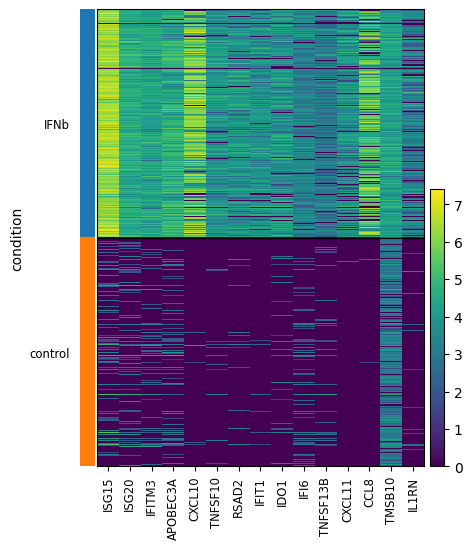

In [43]:
scat.pl.active_genes_heatmap(adata_norm, candidate_genes[:15], groupby="condition");

`comet_plot`, `bias_diagnostic_plot`, and `velocity_phase_portraits` need
nascent residual columns. See {doc}`t_gse226488_partition_mechanism` or
{doc}`t_synthetic_visualization`.

New in 0.10.16, demonstrated above: `compare_de_across_groups` +
`pl.de_summary_barplot` (the cell-type loop, in one call), `pl.group_stat_plot`
(logFC by cell type with a significance bracket), and `pl.enrich_network_plot`
(the GO enrichment map before/after `simplify_enrichment`).

User guide: {doc}`../user_guide/standalone_de`, {doc}`../user_guide/enrichment`,
{doc}`../user_guide/workflow`.